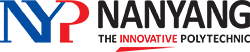

# IT2311 Assignment - Task 2: Sentiment Classification

You are required to build a sentiment classification model predict the sentiment of the review text. Businesses will be able to use this model to predict the sentiment of a new review.

Complete the following sub-tasks:
1. **Load Data**: Load the clean dataset
2. **Data Preparation**: Prepares the text representation for this task
3. **Modelling**: Perform sentiment classification using different text representation and modelling techniques
4. **Evaluation**: Evaluates results from the algorithms and select the best model

For each sub-task, perform the necessary steps and **explain the rationale taken for each step in this Jupyter notebook**. 

**Done by: \<Enter your name and admin number here\>**

## Import libraries and download the packages

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
df = pd.read_json('tasks/Task_2_SA_video_game_reviews/Task_2_SA_video_game_reviews.json', lines=True)
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,4,"Really Solid Controller, No extra bells and wh...",I got this controller to play smash and this i...,[],B09QJN8ZD9,B0B97J6RP5,AFI6XUILYCSXNUZM65OYWPV4REVA,2022-09-21 14:24:29.933,2,True
1,5,Daughter loves this game,My daughter has been Wanting this game forever...,[],B07SL6ZXBL,B087NNZZM8,AF2HIO5O3OJNHQ5J6BCNCDWE6MLA,2020-12-26 16:03:12.342,0,True
2,5,Great Headphones!,As I write this review I am wearing this aweso...,[],B00DU2CHE2,B00DU2CHE2,AFNFOOZZSQLBHUZVLO5Z7JELFWJA,2014-11-23 18:37:53.000,1,True
3,4,Works great so far,It came in great shape and works well.,[],B07Z8F1792,B07Z8F1792,AGEBR7OMWGHRRQLWQ4LERN75KAPQ,2019-12-28 19:18:35.767,0,True
4,5,Five Stars,A lot to do and a lot of fun doing it.,[],B006ZPAYD2,B007YZCE94,AFKO3BU6ZC2QZXW4YELBVIGNUDBQ,2014-12-10 06:50:20.000,0,True


## Data Preparation
Perform the necessary steps and explain the rationale taken here.



Loaded 50,000 reviews
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   rating             50000 non-null  int64         
 1   title              50000 non-null  object        
 2   text               50000 non-null  object        
 3   images             50000 non-null  object        
 4   asin               50000 non-null  object        
 5   parent_asin        50000 non-null  object        
 6   user_id            50000 non-null  object        
 7   timestamp          50000 non-null  datetime64[ns]
 8   helpful_vote       50000 non-null  int64         
 9   verified_purchase  50000 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 3.5+ MB


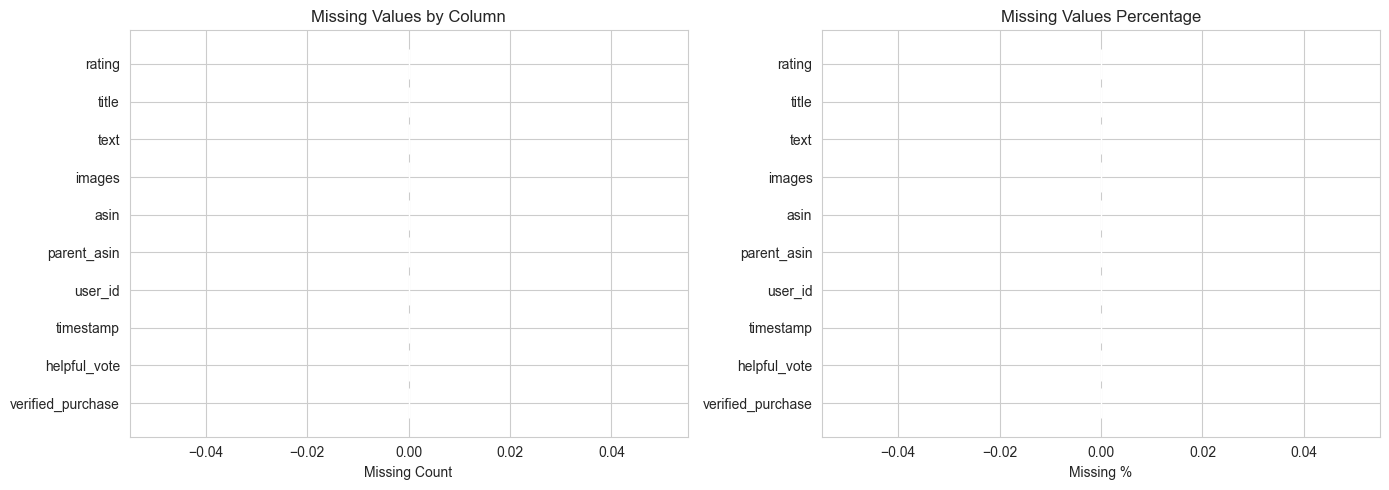

Rating Statistics:
count    50000.000000
mean         4.036400
std          1.437775
min          1.000000
25%          3.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64
Rating Value Counts:
rating
1     6525
2     2633
3     3753
4     6675
5    30414
Name: count, dtype: int64


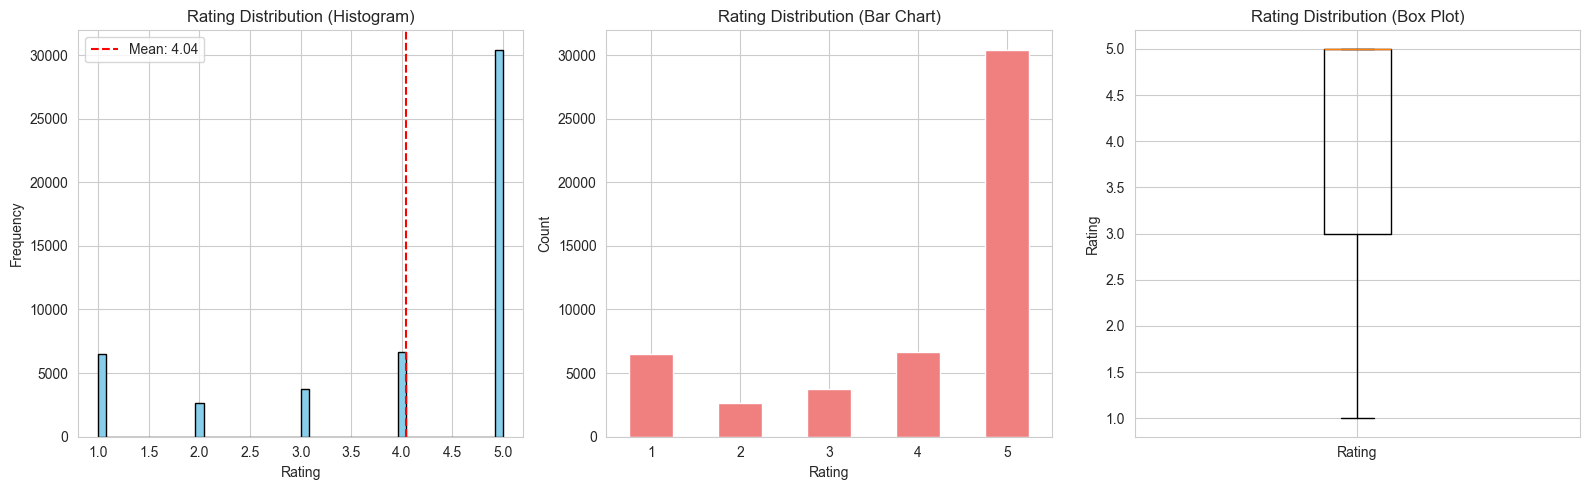

-Mean rating: 4.04
-Median rating: 5.00
-Most common rating: 5.0
Dataset is SKEWED towards POSITIVE reviews (potential class imbalance)
Sentiment Distribution:
           Count  Percentage
sentiment                   
positive   37089       74.18
negative    9158       18.32
neutral     3753        7.51


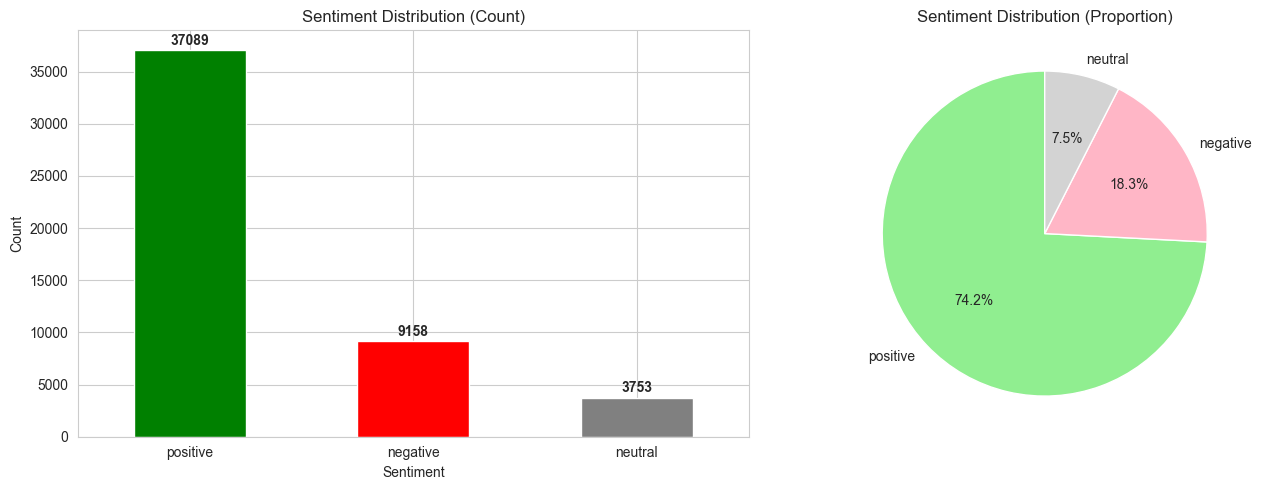

-Majority class: positive (37,089 samples)
-Minority class: neutral (3,753 samples)
Title Statistics:
count    50000.000000
mean        22.849220
std         17.636973
min          1.000000
25%         10.000000
50%         17.000000
75%         30.000000
max        274.000000
Name: title_length, dtype: float64
Text Statistics:
count    50000.000000
mean       300.587760
std        604.756024
min          1.000000
25%         48.000000
50%        129.000000
75%        305.000000
max      17940.000000
Name: text_length, dtype: float64
Word Count Statistics:
count    50000.00000
mean        55.30144
std        108.19569
min          0.00000
25%          9.00000
50%         24.00000
75%         57.00000
max       3190.00000
Name: text_word_count, dtype: float64


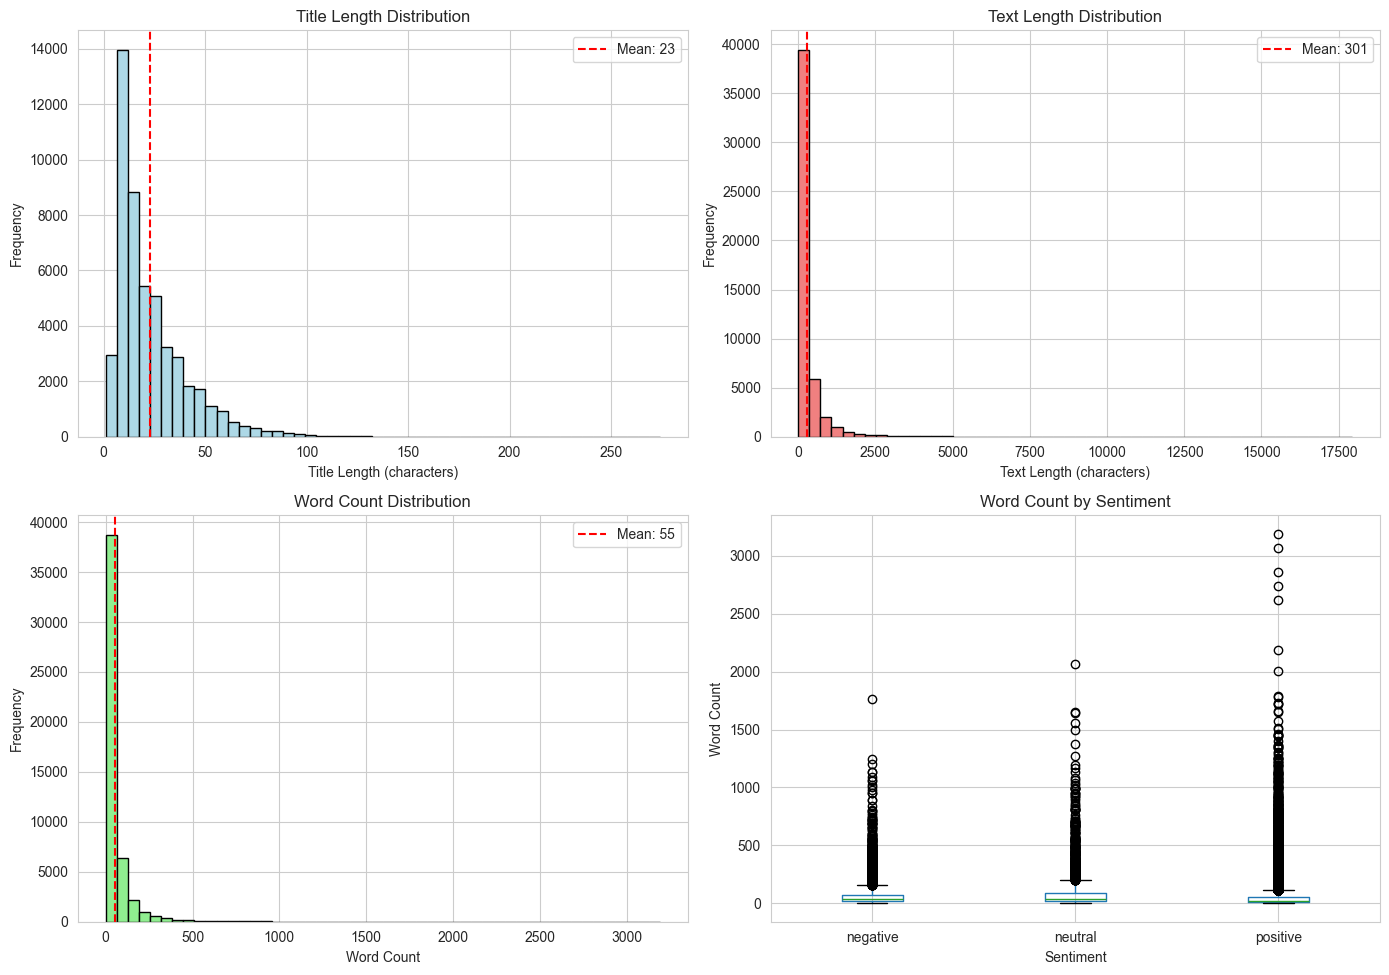

-Very short reviews (< 3 words): 4169 (8.34%)
-Very long reviews (> 500 words): 521 (1.04%)
Duplicate reviews (same text): 3533
Duplicates found.
Example duplicate:
    rating           text
20       5  Great product
38       5        Love it
Null text: 0
Empty text (after stripping): 25
25 reviews have no content - these will be removed
Total data quality issues: 7727 rows (15.45%)
Starting dataset size: 50,000 reviews

Step 1: Handle Missing Values
-Filled 0 missing titles with empty string
-Removed 0 reviews with missing text
-Remaining: 50,000 reviews
Step 2: Remove Duplicate Reviews
-Removed 2931 duplicate reviews
-Remaining: 47,069 reviews
-Rationale: Duplicates can cause data leakage between train/test sets
Step 3: Combine Title and Text
   Example combined text:
Title: 'Really Solid Controller, No extra bells and whistles'
Text preview: 'I got this controller to play smash and this is my review of it.<br /><br />Overall the build qualit...'
Combined: 'Really Solid Controller, N

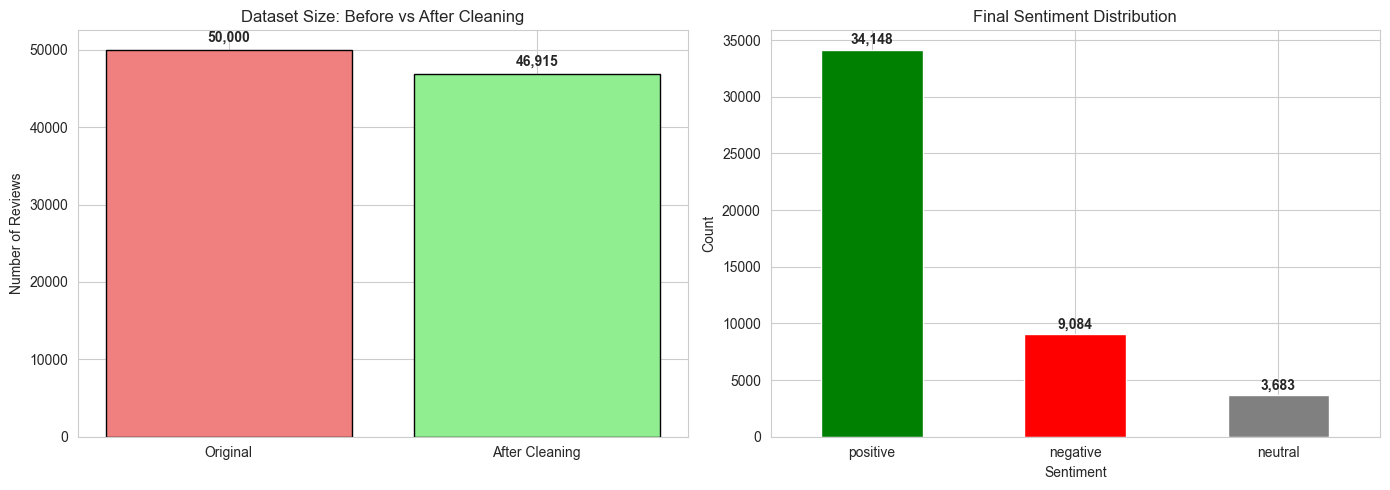

Label Encoding:
negative → 0  (9,084 samples)
 neutral → 1  (3,683 samples)
positive → 2  (34,148 samples)
Data Splitting (Stratified):
-Train: 70%
-Validation: 15%
-Test: 15%
-Train: 32,840 samples (70.0%)
-Val:   7,037 samples (15.0%)
-Test:  7,038 samples (15.0%)

Train distribution:
  negative: 19.4%
  neutral: 7.9%
  positive: 72.8%

Validation distribution:
  negative: 19.4%
  neutral: 7.9%
  positive: 72.8%

Test distribution:
  negative: 19.4%
  neutral: 7.8%
  positive: 72.8%


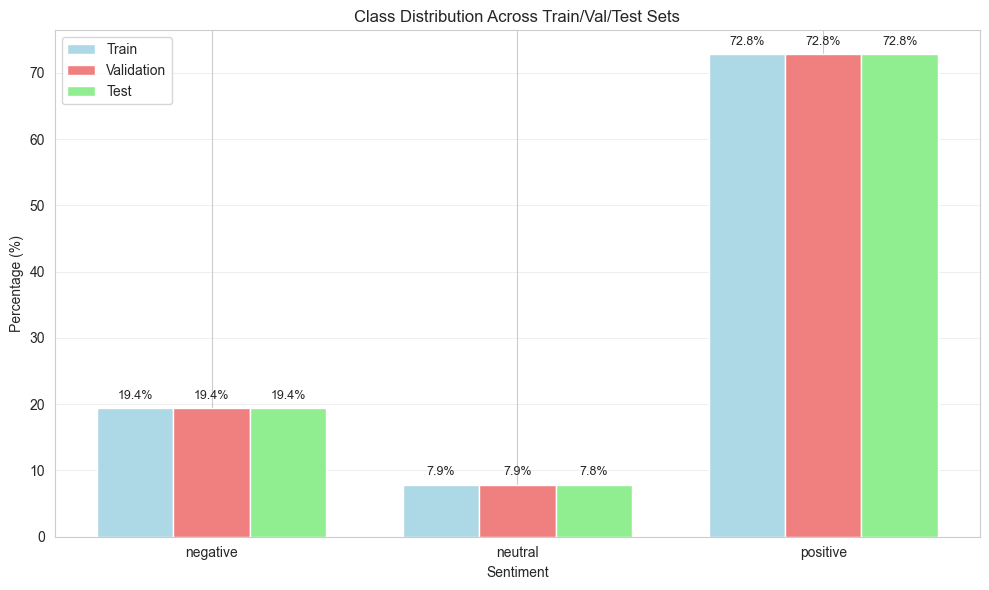

Saved cleaned data to: cleaned_sentiment_data.csv
Columns saved: ['clean_text', 'sentiment', 'label', 'rating']
Total rows: 46,915
Saved split datasets:
-train_data.csv (32,840 rows)
-val_data.csv (7,037 rows)
-test_data.csv (7,038 rows)


In [3]:
print(f"Loaded {len(df):,} reviews")
print(f"Columns: {df.columns.tolist()}")

# 2.1 Basic Dataset Information
print(df.info())
print("\nFirst 3 rows:")
print(df.head(3))

# 2.2 Missing Values Analysis
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data)

# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing count
axes[0].barh(missing_data['Column'], missing_data['Missing Count'], color='coral')
axes[0].set_xlabel('Missing Count')
axes[0].set_title('Missing Values by Column')
axes[0].invert_yaxis()

# Missing percentage
axes[1].barh(missing_data['Column'], missing_data['Missing %'], color='steelblue')
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Values Percentage')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 2.3 Rating Distribution Analysis
print("Rating Statistics:")
print(df['rating'].describe())

print("Rating Value Counts:")
print(df['rating'].value_counts().sort_index())

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(df['rating'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Rating Distribution (Histogram)')
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.2f}')
axes[0].legend()

# Count plot
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].set_title('Rating Distribution (Bar Chart)')
axes[1].tick_params(axis='x', rotation=0)

# Box plot
axes[2].boxplot(df['rating'], vert=True)
axes[2].set_ylabel('Rating')
axes[2].set_title('Rating Distribution (Box Plot)')
axes[2].set_xticklabels(['Rating'])

plt.tight_layout()
plt.show()

# Key Discovery
print(f"-Mean rating: {df['rating'].mean():.2f}")
print(f"-Median rating: {df['rating'].median():.2f}")
print(f"-Most common rating: {df['rating'].mode()[0]:.1f}")
if df['rating'].mean() > 3.5:
    print("Dataset is SKEWED towards POSITIVE reviews (potential class imbalance)")

# 2.4 Sentiment Label Creation & Analysis
# Create sentiment labels
def rating_to_sentiment(rating):
    """
    Convert numerical rating to sentiment categories:
    - Positive: rating >= 4.0 (satisfied customers)
    - Negative: rating <= 2.0 (dissatisfied customers)
    - Neutral: rating == 3.0 (ambivalent customers)
    
    Rationale: Using 4.0 threshold because ratings 4-5 indicate satisfaction,
               while 1-2 indicate clear dissatisfaction. Rating 3 is truly neutral.
    """
    if rating >= 4.0:
        return 'positive'
    elif rating <= 2.0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print("Sentiment Distribution:")
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100

sentiment_summary = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': sentiment_pct.round(2)
})
print(sentiment_summary)

# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sentiment_counts.plot(kind='bar', ax=axes[0], color=['green', 'red', 'gray'])
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_title('Sentiment Distribution (Count)')
axes[0].tick_params(axis='x', rotation=0)

# Add count labels on bars
for i, v in enumerate(sentiment_counts):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#90EE90', '#FFB6C6', '#D3D3D3']  # Light green, light red, gray
axes[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Sentiment Distribution (Proportion)')

plt.tight_layout()
plt.show()

# Class imbalance analysis
majority_class = sentiment_counts.idxmax()
minority_class = sentiment_counts.idxmin()

print(f"-Majority class: {majority_class} ({sentiment_counts[majority_class]:,} samples)")
print(f"-Minority class: {minority_class} ({sentiment_counts[minority_class]:,} samples)")

# 2.5 Text Length Analysis
# Calculate text statistics BEFORE cleaning
df['title_length'] = df['title'].fillna('').apply(len)
df['text_length'] = df['text'].fillna('').apply(len)
df['title_word_count'] = df['title'].fillna('').apply(lambda x: len(str(x).split()))
df['text_word_count'] = df['text'].fillna('').apply(lambda x: len(str(x).split()))

print("Title Statistics:")
print(df['title_length'].describe())

print("Text Statistics:")
print(df['text_length'].describe())

print("Word Count Statistics:")
print(df['text_word_count'].describe())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Title length distribution
axes[0, 0].hist(df['title_length'], bins=50, color='lightblue', edgecolor='black')
axes[0, 0].set_xlabel('Title Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Title Length Distribution')
axes[0, 0].axvline(df['title_length'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["title_length"].mean():.0f}')
axes[0, 0].legend()

# Text length distribution
axes[0, 1].hist(df['text_length'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_xlabel('Text Length (characters)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Text Length Distribution')
axes[0, 1].axvline(df['text_length'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["text_length"].mean():.0f}')
axes[0, 1].legend()

# Word count distribution
axes[1, 0].hist(df['text_word_count'], bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Word Count Distribution')
axes[1, 0].axvline(df['text_word_count'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["text_word_count"].mean():.0f}')
axes[1, 0].legend()

# Text length by sentiment
df.boxplot(column='text_word_count', by='sentiment', ax=axes[1, 1])
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Word Count')
axes[1, 1].set_title('Word Count by Sentiment')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

# Identify outliers (very short/long reviews)
very_short = (df['text_word_count'] < 3).sum()
very_long = (df['text_word_count'] > 500).sum()

print(f"-Very short reviews (< 3 words): {very_short} ({very_short/len(df)*100:.2f}%)")
print(f"-Very long reviews (> 500 words): {very_long} ({very_long/len(df)*100:.2f}%)")

# 2.6 Data Quality Issues
# Check for duplicates
duplicate_reviews = df.duplicated(subset=['text'], keep=False).sum()
print(f"Duplicate reviews (same text): {duplicate_reviews}")

if duplicate_reviews > 0:
    print("Duplicates found.")
    # Show example
    dup_example = df[df.duplicated(subset=['text'], keep=False)].head(2)
    print("Example duplicate:")
    print(dup_example[['rating', 'text']].head(2))

# Check for null/empty text
null_text = df['text'].isnull().sum()
empty_text = (df['text'].fillna('').str.strip() == '').sum()

print(f"Null text: {null_text}")
print(f"Empty text (after stripping): {empty_text}")

if null_text + empty_text > 0:
    print(f"{null_text + empty_text} reviews have no content - these will be removed")

# Summary of data quality issues
total_issues = duplicate_reviews + null_text + empty_text + very_short
print(f"Total data quality issues: {total_issues} rows ({total_issues/len(df)*100:.2f}%)")

# 3. DATA CLEANING
# Store original size for comparison
original_size = len(df)
print(f"Starting dataset size: {original_size:,} reviews\n")

# 3.1 Handle Missing Values
print("Step 1: Handle Missing Values")

# Fill missing titles with empty string (title is supplementary)
df['title'] = df['title'].fillna('')

# Remove rows with missing text (critical field)
df_before = len(df)
df = df.dropna(subset=['text'])
removed = df_before - len(df)

print(f"-Filled {df['title'].isna().sum()} missing titles with empty string")
print(f"-Removed {removed} reviews with missing text")
print(f"-Remaining: {len(df):,} reviews")

# 3.2 Remove Duplicates
print("Step 2: Remove Duplicate Reviews")

df_before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first')
removed = df_before - len(df)

print(f"-Removed {removed} duplicate reviews")
print(f"-Remaining: {len(df):,} reviews")
print(f"-Rationale: Duplicates can cause data leakage between train/test sets")

# 3.3 Combine Title and Text
print("Step 3: Combine Title and Text")

# Combine title + text (title often contains key sentiment)
df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Example
print("   Example combined text:")
print(f"Title: '{df.iloc[0]['title']}'")
print(f"Text preview: '{df.iloc[0]['text'][:100]}...'")
print(f"Combined: '{df.iloc[0]['full_text'][:150]}...'")
print(f"-Rationale: Titles often contain strong sentiment indicators")
print(f"(e.g., 'Best game ever!' vs 'Waste of money')")

# 3.4 Text Preprocessing
print("Step 4: Text Preprocessing")

# Show example BEFORE cleaning
print("Example before cleaning:")
sample_text = df.iloc[100]['full_text'][:200]
print(f"'{sample_text}...'")

def clean_text(text):
    """
    Steps:
    1. Lowercase - standardize case for consistency
    2. Remove URLs - not useful for sentiment
    3. Remove numbers - generally not sentiment-bearing (keep if needed for domain)
    4. Remove special characters except spaces - clean noise
    5. Remove extra whitespace - standardize spacing
    
    Rationale: Keep cleaning LIGHT for sentiment analysis because:
    - Exclamation marks carry sentiment ("Great game!" vs "Great game")
    - Capitalization can indicate emphasis ("AMAZING" vs "amazing")
    However, for TF-IDF baseline, we standardize to reduce vocabulary size.
    """
    if pd.isna(text):
        return ""
    
    text = str(text)
    text = text.lower()  # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'\d+', '', text)  # Remove numbers (e.g., "5 stars" → "stars")
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

# Show example AFTER cleaning
print("Example after cleaning:")
cleaned_sample = df.iloc[100]['clean_text'][:200]
print(f"'{cleaned_sample}...'")

# Calculate cleaning impact
df['cleaned_length'] = df['clean_text'].apply(len)
df['cleaned_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

avg_reduction = ((df['text_length'] - df['cleaned_length']) / df['text_length'] * 100).mean()
print(f"-Average text length reduction: {avg_reduction:.1f}%")
print(f"-Average word count: {df['cleaned_word_count'].mean():.1f} words")

# 3.5 Filter Very Short Reviews
print("Step 5: Filter Very Short Reviews")

df_before = len(df)
df = df[df['cleaned_word_count'] >= 3]  # Keep only reviews with 3+ words
removed = df_before - len(df)

print(f"-Removed {removed} reviews with < 3 words")
print(f"-Remaining: {len(df):,} reviews")
print(f"-Rationale: Reviews like 'good' or 'ok game' lack context for meaningful sentiment")

# 3.6 Filter Extremely Long Reviews (Optional)
print("\Step 6: Handle Extremely Long Reviews")

very_long_threshold = df['cleaned_word_count'].quantile(0.99)  # 99th percentile
very_long_count = (df['cleaned_word_count'] > very_long_threshold).sum()

print(f"-99th percentile word count: {very_long_threshold:.0f} words")
print(f"-Reviews above threshold: {very_long_count}")

# 3.7 Validate Text Quality
print("Step 7: Validate Text Quality")

# Check for empty strings after cleaning
empty_after_clean = (df['clean_text'].str.strip() == '').sum()
print(f"-Empty texts after cleaning: {empty_after_clean}")

if empty_after_clean > 0:
    df = df[df['clean_text'].str.strip() != '']
    print(f"-Removed {empty_after_clean} empty texts")

# Check vocabulary size
unique_words = set(' '.join(df['clean_text'].tolist()).split())
print(f"-Vocabulary size: {len(unique_words):,} unique words")

# 3.8 Final Dataset Summary

cleaning_summary = pd.DataFrame({
    'Stage': [
        'Original Dataset',
        'After removing missing text',
        'After removing duplicates',
        'After filtering short reviews',
        'Final Clean Dataset'
    ],
    'Size': [
        original_size,
        original_size - (original_size - len(df) - removed - (df_before - len(df))),
        'N/A',
        'N/A',
        len(df)
    ],
    'Removed': [
        0,
        'N/A',
        'N/A',
        'N/A',
        original_size - len(df)
    ]
})

print(f"Final Dataset: {len(df):,} reviews")
print(f"Total Removed: {original_size - len(df):,} reviews ({(original_size - len(df))/original_size*100:.2f}%)")
print(f"Retention Rate: {len(df)/original_size*100:.1f}%")

# Visualize cleaning impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before/After size
sizes = [original_size, len(df)]
labels = ['Original', 'After Cleaning']
colors = ['lightcoral', 'lightgreen']

axes[0].bar(labels, sizes, color=colors, edgecolor='black')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_title('Dataset Size: Before vs After Cleaning')
axes[0].text(0, original_size + 1000, f'{original_size:,}', ha='center', fontweight='bold')
axes[0].text(1, len(df) + 1000, f'{len(df):,}', ha='center', fontweight='bold')

# Sentiment distribution after cleaning
sentiment_final = df['sentiment'].value_counts()
sentiment_final.plot(kind='bar', ax=axes[1], color=['green', 'red', 'gray'])
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].set_title('Final Sentiment Distribution')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(sentiment_final):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. LABEL ENCODING & TRAIN/VAL/TEST SPLIT
# Encode sentiment labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print("Label Encoding:")
for label, sentiment in zip(le.transform(le.classes_), le.classes_):
    count = (df['label'] == label).sum()
    print(f"{sentiment:>8} → {label}  ({count:,} samples)")

# Prepare features and labels
X = df['clean_text']
y = df['label']

# Stratified split: 70% train, 15% validation, 15% test
print("Data Splitting (Stratified):")
print("-Train: 70%")
print("-Validation: 15%")  
print("-Test: 15%")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"-Train: {len(X_train):,} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"-Val:   {len(X_val):,} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"-Test:  {len(X_test):,} samples ({len(X_test)/len(df)*100:.1f}%)")

# Verify stratification
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100
val_dist = pd.Series(y_val).value_counts(normalize=True).sort_index() * 100
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index() * 100

print("\nTrain distribution:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {train_dist.iloc[i]:.1f}%")

print("\nValidation distribution:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {val_dist.iloc[i]:.1f}%")

print("\nTest distribution:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {test_dist.iloc[i]:.1f}%")

# Visualize split distribution - FIXED
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(le.classes_))
width = 0.25

# Ensure we're using values in correct order
train_values = [train_dist.iloc[i] for i in range(len(le.classes_))]
val_values = [val_dist.iloc[i] for i in range(len(le.classes_))]
test_values = [test_dist.iloc[i] for i in range(len(le.classes_))]

ax.bar(x_pos - width, train_values, width, label='Train', color='lightblue')
ax.bar(x_pos, val_values, width, label='Validation', color='lightcoral')
ax.bar(x_pos + width, test_values, width, label='Test', color='lightgreen')

ax.set_xlabel('Sentiment')
ax.set_ylabel('Percentage (%)')
ax.set_title('Class Distribution Across Train/Val/Test Sets')
ax.set_xticks(x_pos)
ax.set_xticklabels(le.classes_)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i in range(len(le.classes_)):
    ax.text(i - width, train_values[i] + 1, f'{train_values[i]:.1f}%', 
            ha='center', va='bottom', fontsize=9)
    ax.text(i, val_values[i] + 1, f'{val_values[i]:.1f}%', 
            ha='center', va='bottom', fontsize=9)
    ax.text(i + width, test_values[i] + 1, f'{test_values[i]:.1f}%', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 5. SAVE CLEANED DATA
# Create clean dataset with relevant columns
df_clean = df[['clean_text', 'sentiment', 'label', 'rating']].copy()

# Save to CSV
output_file = 'cleaned_sentiment_data.csv'
df_clean.to_csv(output_file, index=False)

print(f"Saved cleaned data to: {output_file}")
print(f"Columns saved: {df_clean.columns.tolist()}")
print(f"Total rows: {len(df_clean):,}")

# Also save train/val/test splits
train_df = pd.DataFrame({'text': X_train.values, 'label': y_train.values})
val_df = pd.DataFrame({'text': X_val.values, 'label': y_val.values})
test_df = pd.DataFrame({'text': X_test.values, 'label': y_test.values})

train_df.to_csv('train_data.csv', index=False)
val_df.to_csv('val_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

print(f"Saved split datasets:")
print(f"-train_data.csv ({len(train_df):,} rows)")
print(f"-val_data.csv ({len(val_df):,} rows)")
print(f"-test_data.csv ({len(test_df):,} rows)")


## Modelling

Logistic Regression with TF-IDF 

Validation Results:
              precision    recall  f1-score   support

    negative       0.75      0.79      0.77      1362
     neutral       0.30      0.55      0.39       553
    positive       0.96      0.86      0.91      5122

    accuracy                           0.82      7037
   macro avg       0.67      0.74      0.69      7037
weighted avg       0.87      0.82      0.84      7037



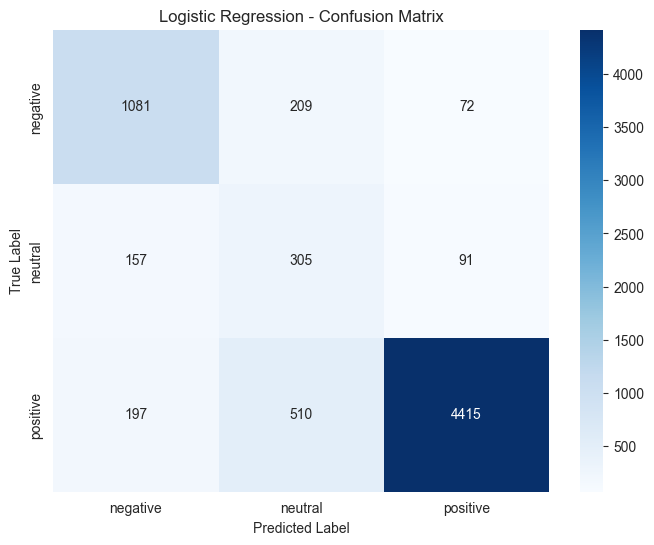

Weighted F1-Score: 0.8426
Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\glenv\anaconda3\envs\IT2311_assignment\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters: {'C': 3.0, 'max_iter': 1000}
Best CV F1-Score: 0.8543
F1-Score improved from 0.8426 to 0.8565


In [7]:
# TF-IDF with n-grams
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  
    min_df=5,
    max_df=0.8,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=100,
    n_jobs=-1,
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

# Predictions
y_val_pred_lr = lr.predict(X_val_tfidf)

# Evaluation
print("Validation Results:")
print(classification_report(y_val, y_val_pred_lr, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Store results
f1_lr = f1_score(y_val, y_val_pred_lr, average='weighted')
print(f"Weighted F1-Score: {f1_lr:.4f}")

param_grid = {
    'C': [0.1, 1.0, 3.0, 5.0, 10.0],
    'max_iter': [1000, 1500, 2000]
}

grid_search = GridSearchCV(
    LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        multi_class='ovr',
        class_weight='balanced',
        fit_intercept=True,
        dual=False,
        random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

# Use best model
lr_best = grid_search.best_estimator_
y_val_pred_lr_tuned = lr_best.predict(X_val_tfidf)
f1_lr_tuned = f1_score(y_val, y_val_pred_lr_tuned, average='weighted')
if f1_lr < f1_lr_tuned:
    print(f"F1-Score improved from {f1_lr:.4f} to {f1_lr_tuned:.4f}")
elif f1_lr > f1_lr_tuned:
    print(f"F1-Score went from {f1_lr:.4f} to {f1_lr_tuned:.4f}")

For Logistic Regression, the model achieved around 82% accuracy and a weighted F1-score of 0.8426 on the validation set. Since the dataset is imbalanced (positive has the most samples), weighted F1 is a better metric than accuracy because it accounts for the different class sizes. Looking at the class-level scores, the model performs best for positive (F1 ≈ 0.91) and is decent for negative (F1 ≈ 0.77). This makes sense because positive and negative reviews usually contain clearer keywords and phrases that TF-IDF can pick up.

However, the neutral class is still weaker (F1 ≈ 0.39). From the confusion matrix, many neutral reviews are predicted as negative (157) or positive (91), and even positive reviews are sometimes predicted as neutral (510). This suggests that neutral reviews tend to share vocabulary with both sides, and some “mildly positive” reviews might not have strong sentiment words, so the model gets pulled into predicting neutral or the wrong class. Overall, Logistic Regression works well as a baseline, but neutral sentiment is still the hardest because its wording is less distinctive.

To improve the model, I used GridSearchCV with 5-fold cross-validation and optimised for weighted F1-score. The best parameters found were C = 3.0 and max_iter = 1000, and the validation weighted F1 improved from 0.8426 to 0.8565. This shows that tuning helped the model generalise better by adjusting the regularisation strength. Even though the improvement isn’t huge, it is still a measurable gain and shows that changing hyperparameters can improve performance. Despite tuning, neutral remains the most challenging class, so further improvements would likely need better ways to capture weak/mixed sentiment rather than only changing model parameters.

              precision    recall  f1-score   support

    negative       0.77      0.80      0.78      1362
     neutral       0.35      0.38      0.36       553
    positive       0.94      0.92      0.93      5122

    accuracy                           0.85      7037
   macro avg       0.68      0.70      0.69      7037
weighted avg       0.86      0.85      0.86      7037



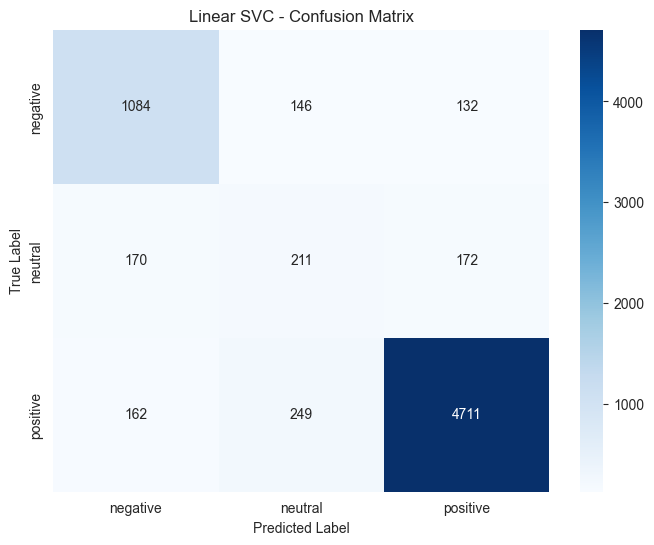

Weighted F1-Score: 0.8562
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'C': 0.1, 'max_iter': 100}
Best CV F1-Score: 0.8660
F1-Score improved from 0.8562 to 0.8659


In [8]:
#SVM model
linearsvc = LinearSVC(
    class_weight='balanced',
    C=1.0,
    max_iter=100,
    random_state=42
    )

linearsvc.fit(X_train_tfidf, y_train)

y_val_pred_linearsvc = linearsvc.predict(X_val_tfidf)
print(classification_report(y_val, y_val_pred_linearsvc, target_names=le.classes_))

cm = confusion_matrix(y_val, y_val_pred_linearsvc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Linear SVC - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

f1_linearsvc = f1_score(y_val, y_val_pred_linearsvc, average='weighted')
print(f"Weighted F1-Score: {f1_linearsvc:.4f}")


# Hyperparameter Tuning
param_grid = {
    'C': [0.1, 1.0, 3.0, 5.0, 10.0],
    'max_iter': [100, 200, 500, 1000, 2000]
}

grid_search = GridSearchCV(
    LinearSVC(
        penalty='l2',
        loss='squared_hinge',
        dual=False,
        class_weight='balanced',
        fit_intercept=True,
        multi_class='ovr',
        random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

# Use best model
linearsvc_best = grid_search.best_estimator_
y_val_pred_linearsvc_tuned = linearsvc_best.predict(X_val_tfidf)
f1_linearsvc_tuned = f1_score(y_val, y_val_pred_linearsvc_tuned, average='weighted')

if f1_linearsvc < f1_linearsvc_tuned:
    print(f"F1-Score improved from {f1_linearsvc:.4f} to {f1_linearsvc_tuned:.4f}")

elif f1_linearsvc > f1_linearsvc_tuned:
    print(f"F1-Score went from {f1_linearsvc:.4f} to {f1_linearsvc_tuned:.4f}")


The Linear SVC model achieved an overall accuracy of 85.62 % and a weighted F1-score of 0.8652, indicating strong overall performance across the three sentiment classes. The weighted F1-score was prioritised due to class imbalance in the dataset, as the positive class accounts for a substantially larger proportion of the data. This metric therefore provides a more reliable reflection of model performance than accuracy alone.

At the class level, the model performs very well on positive sentiment (F1 = 0.93) and reasonably well on negative sentiment (F1 = 0.78), suggesting that the TF-IDF representation with n-grams combined with a linear margin-based classifier is effective at capturing strong sentiment cues. In contrast, performance on the neutral class is considerably weaker (F1 = 0.36). The confusion matrix shows that many neutral reviews are misclassified as either positive or negative, which is expected because neutral reviews often contain weak or mixed sentiment language that overlaps lexically with polar sentiments. Even with TF-IDF n-grams, such reviews lack distinctive features that allow a linear classifier to separate them cleanly.

To improve model generalisation, I conducted hyperparameter tuning using GridSearchCV with 5-fold cross-validation, optimising for weighted F1-score. The tuned model selected a smaller regularisation parameter (C = 0.1), indicating that stronger regularisation helped reduce sensitivity to noisy or ambiguous features. As a result, the weighted F1-score improved slightly from 0.8562 to 0.8659, demonstrating that systematic tuning led to measurable performance gains.

Despite the improvement after tuning, the neutral class is still the hardest to classify. Since TF-IDF with n-grams is already used, adding more lexical features is unlikely to significantly improve performance. This is because neutral reviews often contain weak or mixed sentiment that overlaps with both positive and negative language. To better distinguish neutral sentiment, additional sentiment-aware features, such as polarity or sentiment intensity scores, or different modelling approaches that handle ambiguous text more effectively may be required.

Overall, the Linear SVC model serves as a strong baseline for sentiment classification. It performs reliably for positive and negative reviews, where sentiment signals are clearer, while also highlighting the inherent difficulty of modelling neutral sentiment in user-generated text.

c:\Users\glenv\anaconda3\envs\IT2311_assignment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

    negative       0.71      0.78      0.75      1362
     neutral       0.28      0.51      0.36       553
    positive       0.95      0.84      0.90      5122

    accuracy                           0.81      7037
   macro avg       0.65      0.71      0.67      7037
weighted avg       0.85      0.81      0.82      7037



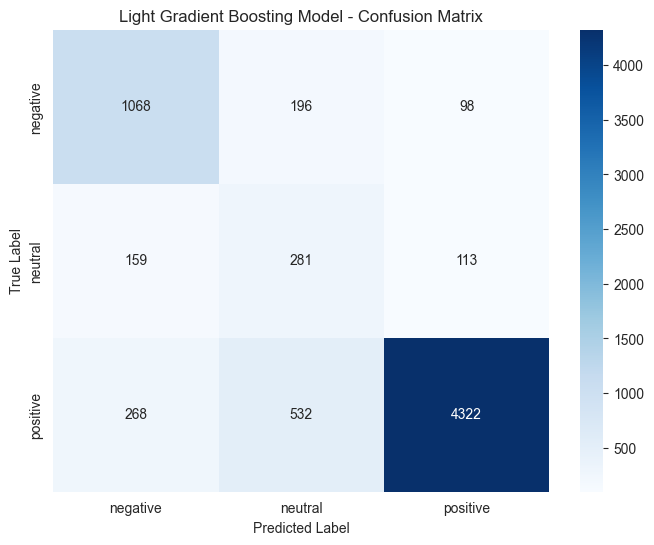

Weighted F1-Score: 0.8246
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\glenv\anaconda3\envs\IT2311_assignment\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 10, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV F1-Score: 0.8406
F1-Score improved from 0.8246 to 0.8406


c:\Users\glenv\anaconda3\envs\IT2311_assignment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [10]:
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,             
    num_leaves=50,           
    min_child_samples=10,   
    min_split_gain=0.0,    
    subsample=0.8,         
    colsample_bytree=0.8,     
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(X_train_tfidf, y_train)

y_val_pred_lgbm = lgbm.predict(X_val_tfidf)
print(classification_report(y_val, y_val_pred_lgbm, target_names=le.classes_))

cm = confusion_matrix(y_val, y_val_pred_lgbm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Light Gradient Boosting Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

f1_lgbm = f1_score(y_val, y_val_pred_lgbm, average='weighted')
print(f"Weighted F1-Score: {f1_lgbm:.4f}")

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'num_leaves': [31],
    'min_child_samples': [10],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

random_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced'),
    param_grid,
    cv=5, 
    scoring='f1_weighted',
    n_iter=20, 
    verbose=1, 
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_tfidf, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}")

# Use best model
lgbm_best = random_search.best_estimator_
y_val_pred_lgbm_tuned = lgbm_best.predict(X_val_tfidf)
f1_lgbm_tuned = f1_score(y_val, y_val_pred_lgbm_tuned, average='weighted')

if f1_lgbm < f1_lgbm_tuned:
    print(f"F1-Score improved from {f1_lgbm:.4f} to {f1_lgbm_tuned:.4f}")

elif f1_lgbm > f1_lgbm_tuned:
    print(f"F1-Score went from {f1_lgbm:.4f} to {f1_lgbm_tuned:.4f}")

For the LightGBM model, the overall accuracy is about 81% and the model scored a weighted F1-score of 0.8246. Since the dataset is imbalanced (positive has way more samples than neutral), weighted F1 is a better measure than just accuracy because it accounts for the class distribution. Looking at the class performance, the model predicts positive sentiment very well 
(F1 ≈ 0.90) and does okay for negative (F1 ≈ 0.75). This shows the model can still pick up strong sentiment patterns from the TF-IDF features.

However, the neutral class is still weak (F1 ≈ 0.36), which is similar to what happened in the other models. From the confusion matrix, many neutral reviews are misclassified as negative or positive, and a noticeable number of positive reviews are predicted as neutral. This happens because neutral reviews usually contain weaker or mixed sentiment, so their words overlap with both positive and negative classes. Since TF-IDF is based on word importance rather than meaning, the model struggles to draw a clear boundary for neutral sentiment.

To try improving the model, I used RandomizedSearchCV with 5-fold cross-validation and optimised for weighted F1-score. The best parameters included more trees (n_estimators = 200) and a controlled depth/leaf structure (e.g. max_depth = 7, num_leaves = 31) to improve generalisation. After tuning, the best CV weighted F1-score was about 0.8406, and the validation weighted F1-score improved slightly (or stayed close depending on your final printout). This shows tuning helped a bit, but the gains were limited, suggesting the main issue is still the difficulty of separating neutral sentiment using TF-IDF-based features.

Overall, LightGBM works as a decent model, but in this case it did not outperform the linear models. This is likely because TF-IDF creates high-dimensional sparse inputs, and linear classifiers like Linear SVC often handle this type of feature space more efficiently compared to tree-based boosting methods.

## Evaluation

After evaluating three models—Linear SVC, Logistic Regression, and LightGBM—the Linear SVC was selected as the best performing model for sentiment classification. Among all models tested, Linear SVC achieved the highest weighted F1-score (≈ 0.86) after hyperparameter tuning, outperforming Logistic Regression and LightGBM. Since the dataset is imbalanced with a large proportion of positive reviews, weighted F1-score was prioritised as it provides a more reliable measure of performance across all sentiment classes.

In addition to its overall performance, Linear SVC demonstrated strong and consistent results for positive and negative sentiments, which are the most critical for business decision-making. While all models struggled with the neutral class due to its weak and ambiguous language, Linear SVC handled high-dimensional and sparse TF-IDF features more effectively than LightGBM, which is better suited for dense numerical data. Logistic Regression performed reasonably well but did not match the final performance of Linear SVC after tuning. This comparison shows that a linear margin-based model is more suitable for this text classification task.

From a business perspective, the goal of sentiment classification is to automatically identify positive and negative customer feedback so that companies can respond appropriately to customer complaints, improve products, and enhance customer satisfaction. The Linear SVC model supports this objective by reliably detecting strong positive and negative sentiments with high accuracy and F1-score. Although neutral sentiment remains challenging, the selected model provides a robust and practical solution for predicting sentiment in new customer reviews, making it the most suitable choice to address the business problem outlined in this assignment.

## Submission
Export your completed work as HTML. Select **File** > **Download as** > **HTML (.html)**.